<a href="https://colab.research.google.com/github/Pradxpk-88/Major_Project_Labmentix/blob/main/Major_Project_Labmentix_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- LOADING DATA ---
Users Shape: (1340, 5)
Flights Shape: (271888, 10)
Hotels Shape: (40552, 8)

--- DATA CLEANING ---
Missing values handled in Users 'gender' column.
Duplicates in Users: 0
Duplicates in Flights: 0
Duplicates in Hotels: 0
Flight Price Outliers detected: 0
Hotel Price Outliers detected: 0

--- GENERATING EDA VISUALIZATIONS ---


/tmp/ipykernel_908/785290623.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=users, x='gender', ax=axes[1], palette='Set2')
/tmp/ipykernel_908/785290623.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=users[users['company'].isin(top_companies)], y='company', ax=axes[2], palette='pastel', order=top_companies)


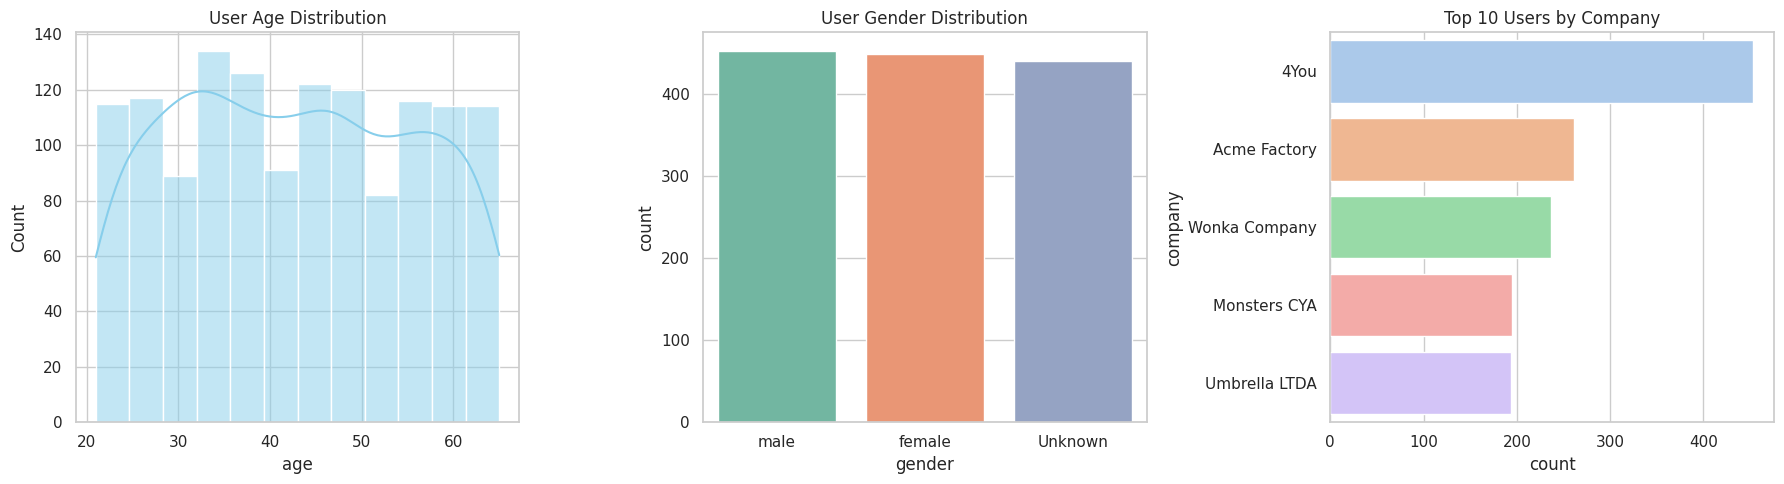

/tmp/ipykernel_908/785290623.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=flights, x='flightType', ax=axes[1], palette='Set1', order=flights['flightType'].value_counts().index)
/tmp/ipykernel_908/785290623.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=flights, x='flightType', y='price', ax=axes[2], palette='Set1', order=flights['flightType'].value_counts().index)


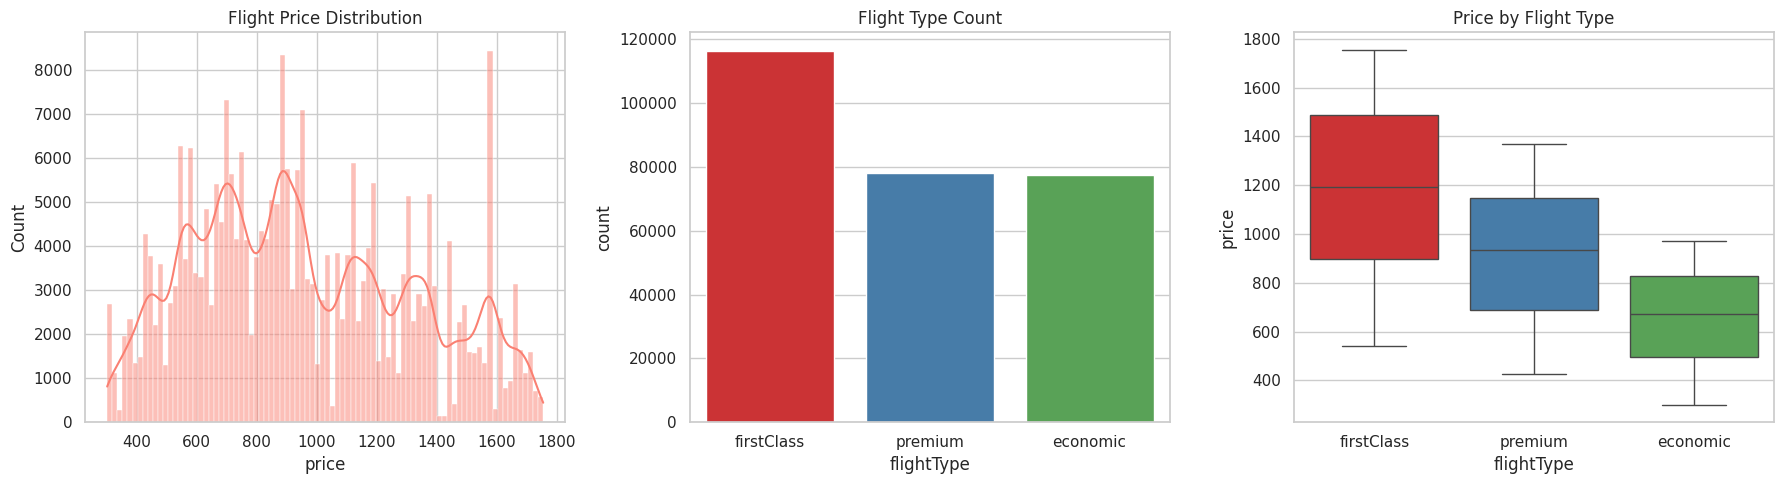

/tmp/ipykernel_908/785290623.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hotels, x='days', ax=axes[1], palette='Set3')
/tmp/ipykernel_908/785290623.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hotels, x='days', y='total', ax=axes[2], palette='Set3')


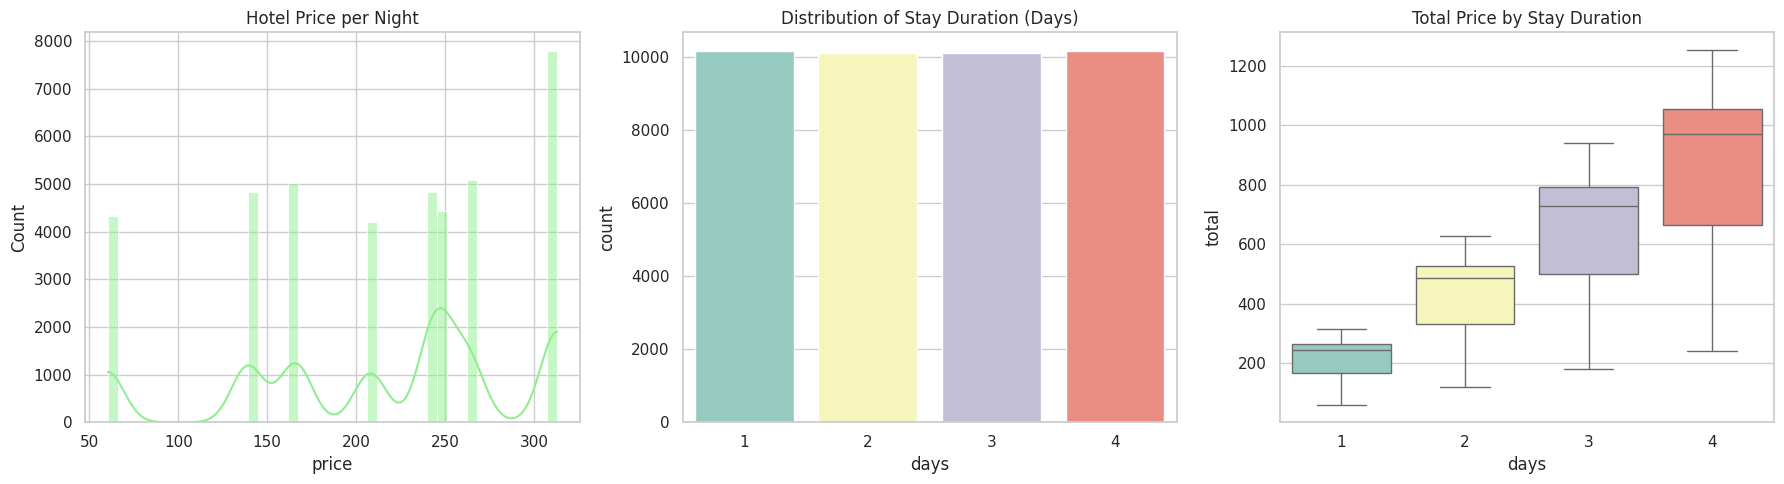


--- HYPOTHESIS TESTING ---
H1: Is there a significant difference in prices between First Class and Economic flights?
T-statistic: 425.1398, P-value: 0.0000e+00
Conclusion: Reject Null Hypothesis. There is a significant difference.

H2: Does stay duration significantly affect the hotel price per night?
F-statistic: 0.7361, P-value: 5.3029e-01
Conclusion: Fail to reject Null Hypothesis. Duration does not affect per-night price significantly.

--- SAVING CLEANED DATASETS ---
Data saved as 'cleaned_users.csv', 'cleaned_flights.csv', and 'cleaned_hotels.csv'.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# T1-T3: DATA UNDERSTANDING

print("--- LOADING DATA ---")
users = pd.read_csv('users.csv')
flights = pd.read_csv('flights.csv')
hotels = pd.read_csv('hotels.csv')

print(f"Users Shape: {users.shape}")
print(f"Flights Shape: {flights.shape}")
print(f"Hotels Shape: {hotels.shape}")

# T4: DATA CLEANING & MISSING VALUES

print("\n--- DATA CLEANING ---")
# The users dataset has 'none' values in the gender column which act as missing data (440 entries)
users['gender'] = users['gender'].fillna('none').replace('none', 'Unknown')
print("Missing values handled in Users 'gender' column.")


# T5: REMOVE DUPLICATES & OUTLIERS

# Checking for duplicates
print(f"Duplicates in Users: {users.duplicated().sum()}")
print(f"Duplicates in Flights: {flights.duplicated().sum()}")
print(f"Duplicates in Hotels: {hotels.duplicated().sum()}")

# Checking for Outliers using the IQR Method
def get_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] < lower_bound) | (df[col] > upper_bound)]

flight_outliers = get_outliers(flights, 'price')
hotel_outliers = get_outliers(hotels, 'price')
print(f"Flight Price Outliers detected: {len(flight_outliers)}")
print(f"Hotel Price Outliers detected: {len(hotel_outliers)}")


# T6-T8: EXPLORATORY DATA ANALYSIS (EDA)

print("\n--- GENERATING EDA VISUALIZATIONS ---")
sns.set_theme(style="whitegrid")

# T6: User Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(users['age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('User Age Distribution')

sns.countplot(data=users, x='gender', ax=axes[1], palette='Set2')
axes[1].set_title('User Gender Distribution')

# Top 10 companies for cleaner visualization
top_companies = users['company'].value_counts().head(10).index
sns.countplot(data=users[users['company'].isin(top_companies)], y='company', ax=axes[2], palette='pastel', order=top_companies)
axes[2].set_title('Top 10 Users by Company')
plt.tight_layout()
plt.show()

# T7: Flight Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(flights['price'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Flight Price Distribution')

sns.countplot(data=flights, x='flightType', ax=axes[1], palette='Set1', order=flights['flightType'].value_counts().index)
axes[1].set_title('Flight Type Count')

sns.boxplot(data=flights, x='flightType', y='price', ax=axes[2], palette='Set1', order=flights['flightType'].value_counts().index)
axes[2].set_title('Price by Flight Type')
plt.tight_layout()
plt.show()

# T8: Hotel Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(hotels['price'], kde=True, ax=axes[0], color='lightgreen')
axes[0].set_title('Hotel Price per Night')

sns.countplot(data=hotels, x='days', ax=axes[1], palette='Set3')
axes[1].set_title('Distribution of Stay Duration (Days)')

sns.boxplot(data=hotels, x='days', y='total', ax=axes[2], palette='Set3')
axes[2].set_title('Total Price by Stay Duration')
plt.tight_layout()
plt.show()


# HYPOTHESIS TESTING

print("\n--- HYPOTHESIS TESTING ---")

# H1: Flight Prices (First Class vs Economic)
first_class = flights[flights['flightType'] == 'firstClass']['price']
economic = flights[flights['flightType'] == 'economic']['price']
t_stat_flights, p_val_flights = stats.ttest_ind(first_class, economic, equal_var=False)

print("H1: Is there a significant difference in prices between First Class and Economic flights?")
print(f"T-statistic: {t_stat_flights:.4f}, P-value: {p_val_flights:.4e}")
if p_val_flights < 0.05:
    print("Conclusion: Reject Null Hypothesis. There is a significant difference.\n")
else:
    print("Conclusion: Fail to reject Null Hypothesis.\n")

# H2: Hotel Prices per Night across Stay Durations
days_groups = [hotels[hotels['days'] == d]['price'] for d in hotels['days'].unique()]
f_stat_hotels, p_val_hotels = stats.f_oneway(*days_groups)

print("H2: Does stay duration significantly affect the hotel price per night?")
print(f"F-statistic: {f_stat_hotels:.4f}, P-value: {p_val_hotels:.4e}")
if p_val_hotels < 0.05:
    print("Conclusion: Reject Null Hypothesis. Prices differ based on duration.\n")
else:
    print("Conclusion: Fail to reject Null Hypothesis. Duration does not affect per-night price significantly.\n")


# SAVE CLEANED DATASETS FOR THE NEXT TEAM MEMBER

print("--- SAVING CLEANED DATASETS ---")
users.to_csv('cleaned_users.csv', index=False)
flights.to_csv('cleaned_flights.csv', index=False)
hotels.to_csv('cleaned_hotels.csv', index=False)
print("Data saved as 'cleaned_users.csv', 'cleaned_flights.csv', and 'cleaned_hotels.csv'.")
